# H3 — Concentración Geográfica del Revenue

**Hipótesis:** Los estados del sureste de Brasil (SP, RJ, MG, ES) concentran
más del 60% del revenue total de la plataforma.

**Herramientas:** PySpark (groupBy, UDF, window functions) · Matplotlib · Seaborn

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType

HDFS         = os.environ.get('HADOOP_NAMENODE', 'hdfs://namenode:8020')
SPARK_MASTER = os.environ.get('SPARK_MASTER',   'spark://spark-master:7077')
DATA_PATH    = f'{HDFS}/data/olist'
OUT          = '/home/jovyan/work/outputs/graficas'
os.makedirs(OUT, exist_ok=True)

SURESTE    = ['SP', 'RJ', 'MG', 'ES']
REGION_MAP = {
    'SP': 'Sureste', 'RJ': 'Sureste', 'MG': 'Sureste', 'ES': 'Sureste',
    'RS': 'Sur',     'SC': 'Sur',     'PR': 'Sur',
    'BA': 'Nordeste','PE': 'Nordeste','CE': 'Nordeste',
    'GO': 'Centro-Oeste','DF': 'Centro-Oeste','MT': 'Centro-Oeste',
    'PA': 'Norte',   'AM': 'Norte',
}

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 130

In [2]:
spark = SparkSession.builder \
    .appName('H3_Revenue_Geografico') \
    .master(SPARK_MASTER) \
    .config('spark.hadoop.fs.defaultFS', HDFS) \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()
spark.sparkContext.setLogLevel('WARN')

26/04/17 17:36:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [3]:
orders    = spark.read.csv(f'{DATA_PATH}/orders.csv',         header=True, inferSchema=True)
payments  = spark.read.csv(f'{DATA_PATH}/order_payments.csv', header=True, inferSchema=True)
customers = spark.read.csv(f'{DATA_PATH}/customers.csv',      header=True, inferSchema=True)

region_udf = F.udf(lambda s: REGION_MAP.get(s, 'Otro'), StringType())

state_revenue = orders \
    .filter(F.col('order_status') == 'delivered') \
    .join(payments.groupBy('order_id').agg(F.sum('payment_value').alias('revenue')), 'order_id') \
    .join(customers.select('customer_id', 'customer_state'), 'customer_id') \
    .groupBy('customer_state').agg(
        F.sum('revenue').alias('revenue_total'),
        F.count('order_id').alias('n_ordenes')
    ) \
    .withColumn('region', region_udf('customer_state'))

total_rev = state_revenue.agg(F.sum('revenue_total')).collect()[0][0]
state_pd  = state_revenue \
    .withColumn('pct', F.round(F.col('revenue_total') / total_rev * 100, 2)) \
    .orderBy(F.desc('revenue_total')).toPandas()

print(f'Revenue total: ${total_rev:,.2f}')
state_pd.head()

Revenue total: $15,126,201.61


,customer_state,revenue_total,n_ordenes,region,pct
0,SP,3053883.99,12709,Sureste,20.19
1,RJ,2288352.78,9559,Sureste,15.13
2,MG,1780475.86,7325,Sureste,11.77
3,ES,1229358.68,4994,Sureste,8.13
4,RS,871532.47,3689,Sur,5.76


### Gráfica 1 — Revenue por estado

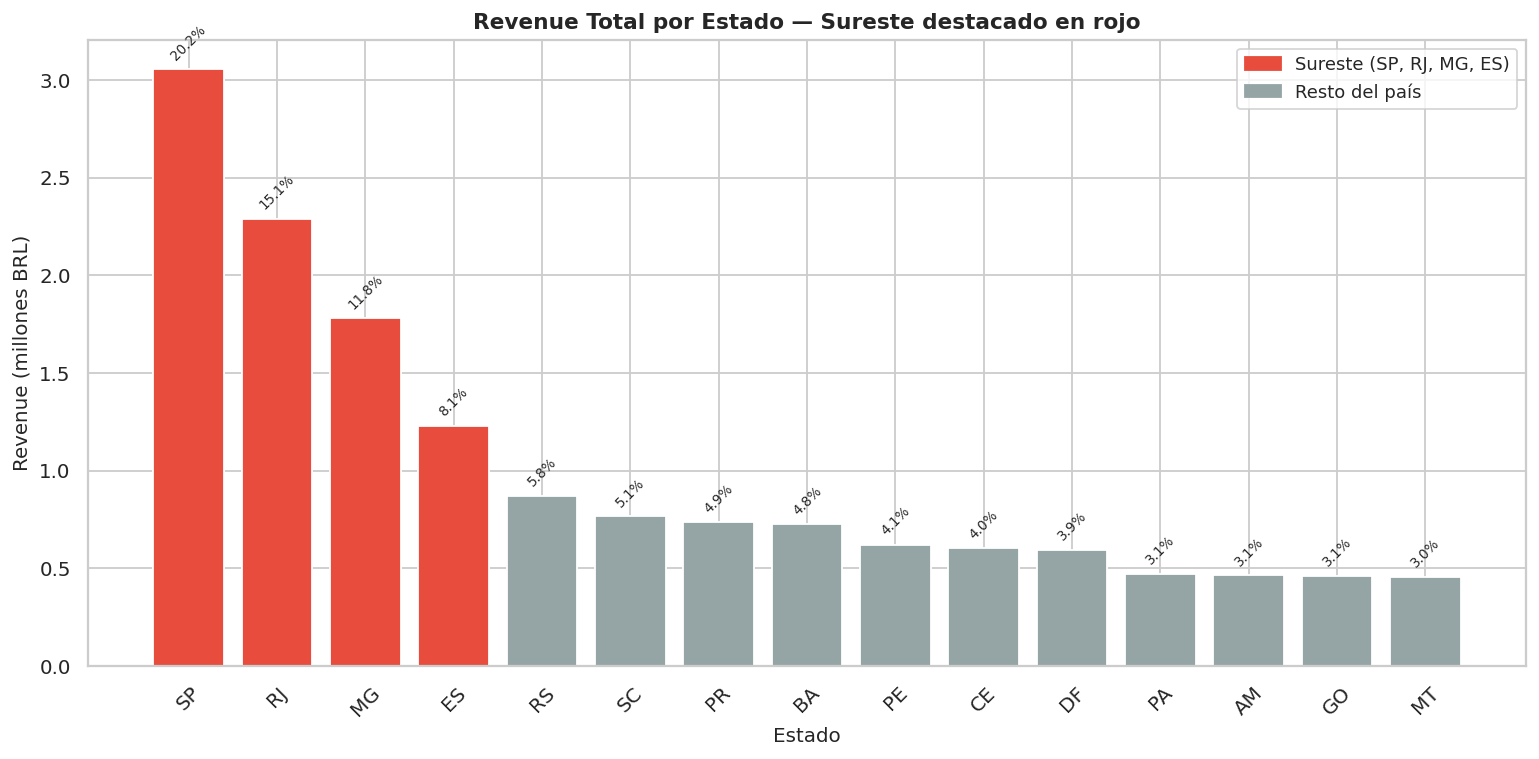

In [4]:
state_pd['color'] = state_pd['customer_state'].apply(
    lambda s: '#e74c3c' if s in SURESTE else '#95a5a6'
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(state_pd['customer_state'], state_pd['revenue_total'] / 1e6,
              color=state_pd['color'], edgecolor='white')
ax.set_xlabel('Estado', fontsize=11)
ax.set_ylabel('Revenue (millones BRL)', fontsize=11)
ax.set_title('Revenue Total por Estado — Sureste destacado en rojo', fontsize=12, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Sureste (SP, RJ, MG, ES)'),
    mpatches.Patch(color='#95a5a6', label='Resto del país')
], fontsize=10)
for bar, pct in zip(bars, state_pd['pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{pct:.1f}%', ha='center', fontsize=7.5, rotation=45)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{OUT}/H3_revenue_por_estado.png', bbox_inches='tight')
plt.show()

### Gráfica 2 — Revenue por región (donut + barras)

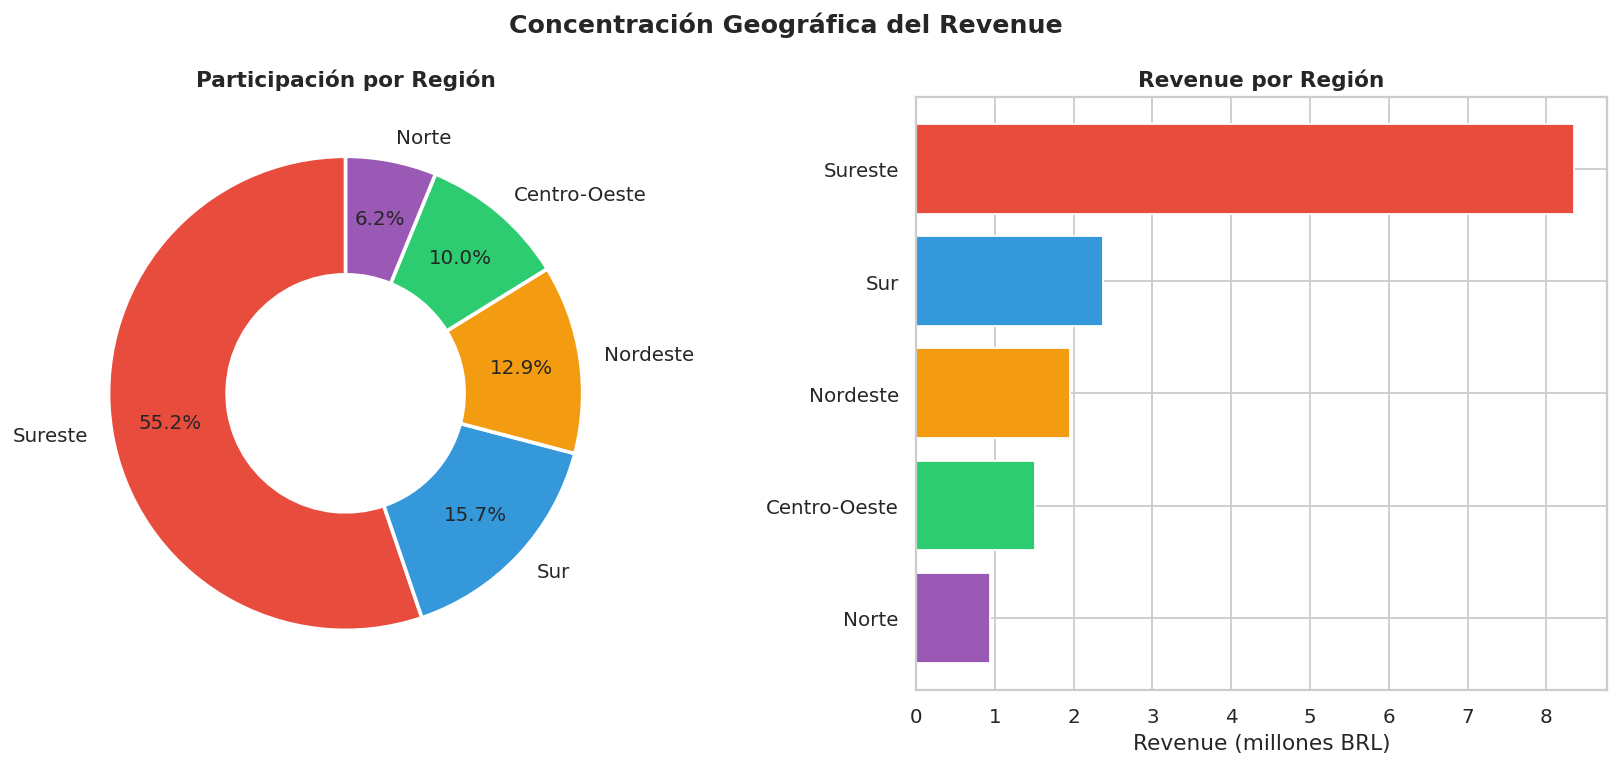

      region  revenue_total
     Sureste     8352071.31
         Sur     2374251.95
    Nordeste     1949913.45
Centro-Oeste     1513542.48
       Norte      936422.42


In [5]:
region_pd = state_pd.groupby('region').agg(
    revenue_total=('revenue_total', 'sum')
).reset_index().sort_values('revenue_total', ascending=False)

region_colors = {'Sureste':'#e74c3c','Sur':'#3498db','Nordeste':'#f39c12',
                 'Centro-Oeste':'#2ecc71','Norte':'#9b59b6'}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].pie(
    region_pd['revenue_total'],
    labels=region_pd['region'],
    colors=[region_colors.get(r, '#bdc3c7') for r in region_pd['region']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    pctdistance=0.75, textprops={'fontsize': 11}
)
axes[0].set_title('Participación por Región', fontsize=12, fontweight='bold')

axes[1].barh(region_pd['region'], region_pd['revenue_total'] / 1e6,
             color=[region_colors.get(r, '#bdc3c7') for r in region_pd['region']])
axes[1].set_xlabel('Revenue (millones BRL)')
axes[1].set_title('Revenue por Región', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('Concentración Geográfica del Revenue', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/H3_revenue_por_region.png', bbox_inches='tight')
plt.show()
print(region_pd.to_string(index=False))

### Gráfica 3 — Curva de Pareto por estado

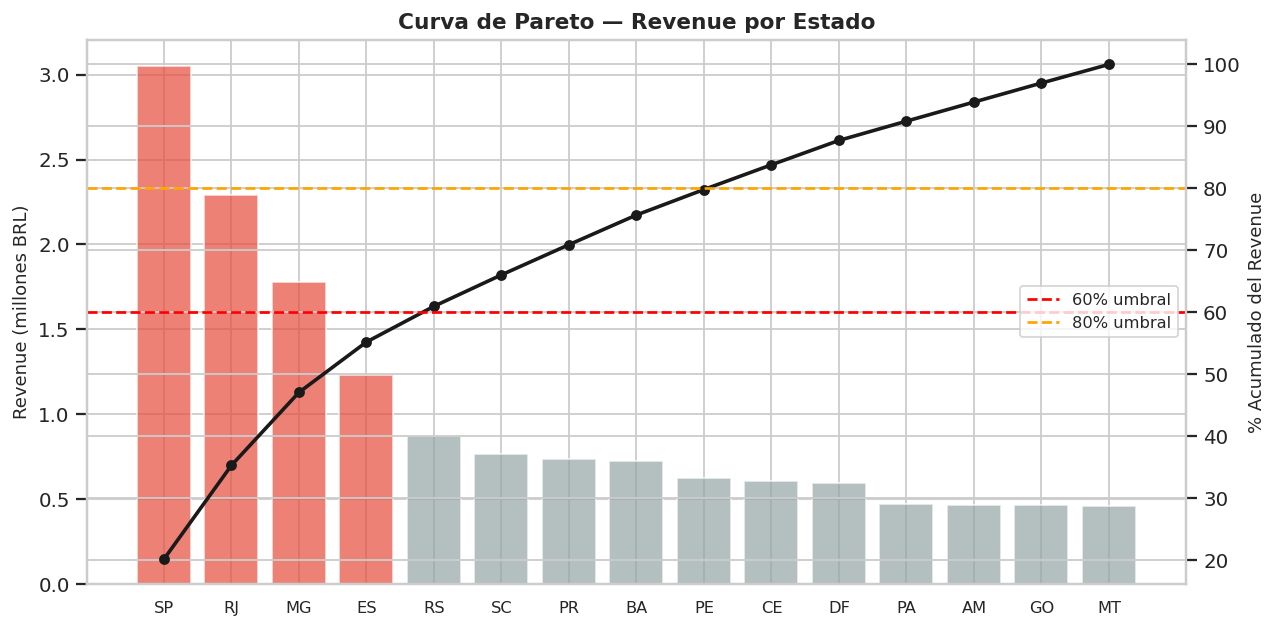

In [6]:
sp = state_pd.sort_values('revenue_total', ascending=False).reset_index(drop=True)
sp['pct_acumulado'] = sp['pct'].cumsum()

fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()
ax.bar(range(len(sp)), sp['revenue_total'] / 1e6, color=sp['color'], alpha=0.7)
ax2.plot(range(len(sp)), sp['pct_acumulado'], 'ko-', linewidth=2, markersize=5)
ax2.axhline(y=60, color='red',    linestyle='--', linewidth=1.5, label='60% umbral')
ax2.axhline(y=80, color='orange', linestyle='--', linewidth=1.5, label='80% umbral')
ax.set_xticks(range(len(sp)))
ax.set_xticklabels(sp['customer_state'], fontsize=9)
ax.set_ylabel('Revenue (millones BRL)', fontsize=10)
ax2.set_ylabel('% Acumulado del Revenue', fontsize=10)
ax.set_title('Curva de Pareto — Revenue por Estado', fontsize=12, fontweight='bold')
ax2.legend(loc='center right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUT}/H3_pareto_estados.png', bbox_inches='tight')
plt.show()

### Conclusión H3

In [7]:
sureste_pct = state_pd[state_pd['customer_state'].isin(SURESTE)]['pct'].sum()
print(f'Revenue del Sureste (SP+RJ+MG+ES): {sureste_pct:.2f}%')
print(f'Umbral de hipótesis:                60.00%')
print()
if sureste_pct >= 60:
    print('CONCLUSIÓN: La hipótesis SE CONFIRMA.')
    print(f'  El sureste concentra {sureste_pct:.1f}% del revenue total.')
print()
print('Top 5 estados:')
print(state_pd[['customer_state','region','revenue_total','pct']].head(5).to_string(index=False))

Revenue del Sureste (SP+RJ+MG+ES): 55.22%
Umbral de hipótesis:                60.00%


Top 5 estados:
customer_state  region  revenue_total   pct
            SP Sureste     3053883.99 20.19
            RJ Sureste     2288352.78 15.13
            MG Sureste     1780475.86 11.77
            ES Sureste     1229358.68  8.13
            RS     Sur      871532.47  5.76


In [8]:
spark.stop()